In [18]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Definir la ruta base de los datos
data_dir = "data"

# Listar el contenido de la carpeta data para verificar la estructura
print("Contenido de data:")
print(os.listdir(data_dir))


Contenido de data:
['ARXIV_V5_CHESTXRAY.pdf', 'BBox_List_2017.csv', 'Data_Entry_2017.csv', 'FAQ_CHESTXRAY.pdf', 'features', 'images_001', 'images_002', 'images_003', 'images_004', 'images_005', 'images_006', 'images_007', 'images_008', 'images_009', 'images_010', 'images_011', 'images_012', 'LOG_CHESTXRAY.pdf', 'README_CHESTXRAY.pdf', 'test_list.txt', 'train_val_list.txt']


In [4]:
# Cargar el archivo CSV con la información de las imágenes y sus etiquetas
csv_path = os.path.join(data_dir, "Data_Entry_2017.csv")
df = pd.read_csv(csv_path)
print("Primeras filas del CSV:")
display(df.head())

# Leer los archivos de lista de imágenes para entrenamiento/validación y test
with open(os.path.join(data_dir, "train_val_list.txt"), "r") as f:
    train_files = f.read().splitlines()
with open(os.path.join(data_dir, "test_list.txt"), "r") as f:
    test_files = f.read().splitlines()

print("Número de imágenes para entrenamiento:", len(train_files))
print("Número de imágenes para test:", len(test_files))


Primeras filas del CSV:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


Número de imágenes para entrenamiento: 86524
Número de imágenes para test: 25596


In [5]:
def find_image_path(img_name):
    # Recorremos las subcarpetas dentro de data que comienzan con "images_"
    for subfolder in os.listdir(data_dir):
        if subfolder.startswith("images_"):
            candidate_path = os.path.join(data_dir, subfolder, "images", img_name)
            if os.path.exists(candidate_path):
                return candidate_path
    return None

# Ejemplo de prueba con la primera imagen de la lista de entrenamiento
ruta_ejemplo = find_image_path(train_files[0])
print("Ruta de la imagen de prueba:", ruta_ejemplo)


Ruta de la imagen de prueba: data\images_001\images\00000001_000.png


In [11]:
#!pip install tqdm

Celda 4: Funciones para extracción de características y almacenamiento en .npy


In [6]:
from tqdm import tqdm  # Para visualizar el avance en tiempo real

# Función para la convolución 2D (sin padding y con stride=1)
def convolve2d(image, kernel):
    kernel_height, kernel_width = kernel.shape
    image_height, image_width = image.shape
    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1
    output = np.zeros((output_height, output_width))
    for i in range(output_height):
        for j in range(output_width):
            region = image[i:i+kernel_height, j:j+kernel_width]
            output[i, j] = np.sum(region * kernel)
    return output

# Función de max pooling 2x2
def max_pooling(feature_map, size=2, stride=2):
    h, w = feature_map.shape
    new_h = h // size
    new_w = w // size
    pooled = np.zeros((new_h, new_w))
    for i in range(new_h):
        for j in range(new_w):
            region = feature_map[i*stride:i*stride+size, j*stride:j*stride+size]
            pooled[i, j] = np.max(region)
    return pooled

# Definir filtros de Sobel para detección de bordes
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# Función para extraer características de una imagen
def extract_features(img_path, target_size=(128,128)):
    # Cargar la imagen en escala de grises y redimensionarla
    img = Image.open(img_path).convert('L')
    img = img.resize(target_size)
    img_array = np.array(img) / 255.0  # Normalización [0,1]
    
    # Aplicar filtros de Sobel
    gx = convolve2d(img_array, sobel_x)
    gy = convolve2d(img_array, sobel_y)
    grad_mag = np.sqrt(gx**2 + gy**2)
    
    # Aplicar max pooling para reducir la dimensionalidad
    pooled = max_pooling(grad_mag, size=2, stride=2)
    
    # Aplanar el resultado para obtener un vector de características
    feature_vector = pooled.flatten()
    return feature_vector


Celda 5: Función para guardar y cargar características en .npy


In [8]:
# Crear una carpeta para almacenar los archivos .npy
features_dir = "npy_features"
if not os.path.exists(features_dir):
    os.makedirs(features_dir)

# Función para guardar características y etiquetas en archivos .npy
def save_features_npy(image_list, split_name):
    X = []
    y = []
    
    # Archivo de salida
    X_file = os.path.join(features_dir, f"X_{split_name}.npy")
    y_file = os.path.join(features_dir, f"y_{split_name}.npy")
    
    # Si ya existen los archivos, se cargan y se retorna
    if os.path.exists(X_file) and os.path.exists(y_file):
        print(f"Cargando características de {split_name} desde archivo .npy")
        X = np.load(X_file)
        y = np.load(y_file)
        return X, y
    
    # Si no existen los archivos, se procede a la extracción
    print(f"Extrayendo características de {split_name}...")
    for fname in tqdm(image_list):
        img_path = find_image_path(fname)
        if img_path is None:
            continue
        
        # Extraer características
        features = extract_features(img_path)
        X.append(features)
        
        # Obtener etiquetas
        label_vector = get_labels(fname, df)
        y.append(label_vector)
    
    # Convertir a arrays de NumPy
    X = np.array(X)
    y = np.array(y)
    
    # Guardar en archivos .npy
    np.save(X_file, X)
    np.save(y_file, y)
    
    print(f"Características de {split_name} guardadas en .npy")
    return X, y


Celda 6: Extracción de características en paralelo para entrenamiento y test


In [9]:
# Extraer y guardar características de entrenamiento y test
X_train, y_train = save_features_npy(train_files, "train")
X_test, y_test = save_features_npy(test_files, "test")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Cargando características de train desde archivo .npy
Cargando características de test desde archivo .npy
X_train shape: (86524, 3969)
y_train shape: (86524, 15)
X_test shape: (25596, 3969)
y_test shape: (25596, 15)


Celda 7: Implementación de la red neuronal desde cero


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

class NeuralNetwork:
    def __init__(self, input_dim, hidden_dim, output_dim, learning_rate=0.01, dropout_rate=0.5, reg_lambda=0.001):
        self.lr = learning_rate
        self.dropout_rate = dropout_rate
        self.reg_lambda = reg_lambda
        # Inicializamos los pesos con valores pequeños
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.01
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.01
        self.b2 = np.zeros((1, output_dim))
        
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def forward(self, X, training=True):
        # Capa oculta
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = np.maximum(0, self.Z1)  # Activación ReLU
        # Aplicar dropout solo durante el entrenamiento
        if training and self.dropout_rate > 0:
            self.dropout_mask = (np.random.rand(*self.A1.shape) > self.dropout_rate).astype(float)
            self.A1 *= self.dropout_mask
            self.A1 /= (1 - self.dropout_rate)
        else:
            self.dropout_mask = np.ones_like(self.A1)
            
        # Capa de salida
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2)
        return self.A2
    
    def compute_loss(self, Y, A2):
        m = Y.shape[0]
        epsilon = 1e-8
        loss = - np.sum(Y * np.log(A2 + epsilon) + (1 - Y) * np.log(1 - A2 + epsilon)) / m
        # Agregar término de regularización L2
        reg_loss = 0.5 * self.reg_lambda * (np.sum(self.W1**2) + np.sum(self.W2**2))
        return loss + reg_loss
    
    def backward(self, X, Y):
        m = X.shape[0]
        # Gradiente respecto a A2
        dA2 = -(Y / (self.A2 + 1e-8)) + ((1 - Y) / (1 - self.A2 + 1e-8))
        dZ2 = dA2 * (self.A2 * (1 - self.A2))
        dW2 = np.dot(self.A1.T, dZ2) / m + self.reg_lambda * self.W2
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m
        
        dA1 = np.dot(dZ2, self.W2.T)
        dA1 *= self.dropout_mask
        dZ1 = dA1 * (self.Z1 > 0)
        dW1 = np.dot(X.T, dZ1) / m + self.reg_lambda * self.W1
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m
        
        # Actualización de parámetros
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        
    def train(self, X, Y, epochs=100, X_val=None, y_val=None):
        self.train_losses = []
        self.val_losses = []
        for i in range(epochs):
            # Forward en entrenamiento
            A2 = self.forward(X, training=True)
            train_loss = self.compute_loss(Y, A2)
            self.train_losses.append(train_loss)
            
            # Backward
            self.backward(X, Y)
            
            # Validación
            if X_val is not None and y_val is not None:
                val_pred = self.forward(X_val, training=False)
                val_loss = self.compute_loss(y_val, val_pred)
                self.val_losses.append(val_loss)
            
            if i % 10 == 0:
                if X_val is not None and y_val is not None:
                    print(f"Epoch {i}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
                else:
                    print(f"Epoch {i}, Loss: {train_loss:.4f}")


Celda 8: Entrenamiento del modelo

In [ ]:
"""
# Definir dimensiones de la red neuronal
input_dim = X_train.shape[1]  # Longitud del vector de características
hidden_dim = 64               # Número de neuronas en la capa oculta
output_dim = y_train.shape[1] # 14 clases

# Inicializamos el modelo con dropout y regularización
nn_model = NeuralNetwork(input_dim, hidden_dim, output_dim, learning_rate=0.01, dropout_rate=0.5, reg_lambda=0.001)

# Entrenar el modelo. Se usa X_test e y_test como conjunto de validación para visualizar la curva.
nn_model.train(X_train, y_train, epochs=100, X_val=X_test, y_val=y_test)
"""


In [28]:
best_val_loss = float('inf')
best_config = None
best_model = None
# Definir dimensiones de la red neuronal
input_dim = X_train.shape[1]  # Longitud del vector de características
output_dim = y_train.shape[1] # 14 clases

for neurons in [32, 64, 128, 256, 512]:
    print(f"\nEntrenando modelo con {neurons} neuronas en la capa oculta...")
    model = NeuralNetwork(input_dim, neurons, output_dim, learning_rate=0.01, dropout_rate=0.5, reg_lambda=0.001)
    model.train(X_train, y_train, epochs=50, X_val=X_test, y_val=y_test)
    current_val_loss = model.val_losses[-1]
    print(f"Configuración: {neurons} neuronas, Pérdida de validación final: {current_val_loss:.4f}")
    
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_config = neurons
        best_model = model

print(f"\nMejor configuración: {best_config} neuronas con una pérdida de validación de {best_val_loss:.4f}")

# Asignar el mejor modelo a nn_model para seguir usando ese nombre en el resto del notebook.
nn_model = best_model



Entrenando modelo con 32 neuronas en la capa oculta...
Epoch 0, Train Loss: 10.4012, Val Loss: 10.3507
Epoch 10, Train Loss: 8.6824, Val Loss: 8.4333
Epoch 20, Train Loss: 4.0947, Val Loss: 4.7436
Epoch 30, Train Loss: 3.4989, Val Loss: 4.4810
Epoch 40, Train Loss: 3.3789, Val Loss: 4.4763
Configuración: 32 neuronas, Pérdida de validación final: 4.4864

Entrenando modelo con 64 neuronas en la capa oculta...
Epoch 0, Train Loss: 10.4300, Val Loss: 10.3427
Epoch 10, Train Loss: 7.5942, Val Loss: 7.3459
Epoch 20, Train Loss: 3.7312, Val Loss: 4.6135
Epoch 30, Train Loss: 3.3664, Val Loss: 4.4918
Epoch 40, Train Loss: 3.2975, Val Loss: 4.4948
Configuración: 64 neuronas, Pérdida de validación final: 4.5028

Entrenando modelo con 128 neuronas en la capa oculta...
Epoch 0, Train Loss: 10.3780, Val Loss: 10.2568
Epoch 10, Train Loss: 6.0495, Val Loss: 6.1353
Epoch 20, Train Loss: 3.4763, Val Loss: 4.5783
Epoch 30, Train Loss: 3.2649, Val Loss: 4.5132
Epoch 40, Train Loss: 3.2161, Val Loss: 4.

Celda 9: Evaluación del modelo en el conjunto de prueba


In [29]:
# Si no se ha definido previamente, define la lista de clases
classes = ["Atelectasis", "Cardiomegaly", "Effusion", "Infiltration", "Mass", "Nodule", 
           "Pneumonia", "Pneumothorax", "Consolidation", "Edema", "Emphysema", "Fibrosis", 
           "Pleural_Thickening", "Hernia"]

# Propagación hacia adelante en el conjunto de test (modo inferencia)
predictions = nn_model.forward(X_test, training=False)
# Convertir probabilidades en etiquetas binarias
pred_labels = (predictions >= 0.5).astype(int)

# Exactitud global (promedio sobre todos los elementos)
overall_accuracy = np.mean(pred_labels == y_test)
print("Exactitud global en test:", overall_accuracy)

# Calcular métricas por clase usando scikit-learn
precision = precision_score(y_test, pred_labels, average='macro', zero_division=0)
recall = recall_score(y_test, pred_labels, average='macro', zero_division=0)
f1 = f1_score(y_test, pred_labels, average='macro', zero_division=0)

print(f"\nPrecisión macro: {precision:.4f}")
print(f"Recall macro: {recall:.4f}")
print(f"F1-score macro: {f1:.4f}")

# También, mostrar exactitud por clase
print("\nExactitud por clase:")
for i, cls in enumerate(classes):
    acc = np.mean(pred_labels[:, i] == y_test[:, i])
    print(f"{cls}: {acc:.4f}")


Exactitud global en test: 0.8881570036984946

Precisión macro: 0.0257
Recall macro: 0.0667
F1-score macro: 0.0371

Exactitud por clase:
Atelectasis: 0.8719
Cardiomegaly: 0.9582
Effusion: 0.9291
Infiltration: 0.9639
Mass: 0.8180
Nodule: 0.9573
Pneumonia: 0.9830
Pneumothorax: 0.9966
Consolidation: 0.7612
Edema: 0.9317
Emphysema: 0.3853
Fibrosis: 0.9366
Pleural_Thickening: 0.9553
Hernia: 0.9783


Celda 10: Visualización de la curva de aprendizaje


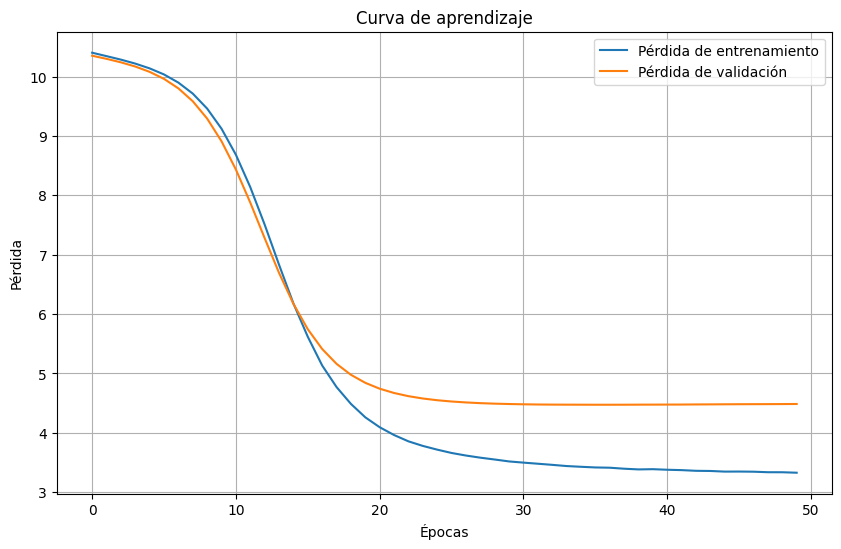

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(nn_model.train_losses, label='Pérdida de entrenamiento')
if len(nn_model.val_losses) > 0:
    plt.plot(nn_model.val_losses, label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curva de aprendizaje')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Evaluación final con el mejor modelo (nn_model)
predictions = nn_model.forward(X_test, training=False)
pred_labels = (predictions >= 0.5).astype(int)

# Accuracy "element-wise": promedio de cada predicción correcta
elementwise_accuracy = np.mean(pred_labels == y_test)

# Accuracy "exact match": porcentaje de muestras en las que se aciertan todas las etiquetas
exact_match_accuracy = np.mean(np.all(pred_labels == y_test, axis=1))

print("Element-wise Accuracy: {:.4f}".format(elementwise_accuracy))
print("Exact Match Accuracy: {:.4f}".format(exact_match_accuracy))


Element-wise Accuracy: 0.8882
Exact Match Accuracy: 0.3853
